In [1]:
import os 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet

from CityScapes.datasets import CityScapesMultiResolutionDataset
from DCGAN.loss_functions import GradientPenaltyLoss, EntropyLoss, DriftLoss, WeightedMSELoss, TotalVariationLoss

device ="cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5)

In [2]:
n_components= 4

encoder_channels = [512,256,128,64,32,32,16]
decoder_channels = [i//2 for i in encoder_channels]
 
degrees_of_freedom = [i//8 for i in decoder_channels]
vectorizer_output_channels = [i *n_components for i in degrees_of_freedom[1:]]

grid_sizes = [1, 2, 4, 8, 16, 16, 16] 

seg_gen_cut_connections = 0

batch_size = 8
rec_model_lr = 1.0e-4
seg_model_lr = 1.0e-5

In [3]:

msg_dataset = CityScapesMultiResolutionDataset()
train_loader = DataLoader(msg_dataset, batch_size=batch_size, shuffle=True)

rec_model = VectorizedUNet(encoder_channels=encoder_channels,
                           decoder_channels=decoder_channels,
                           number_of_components=n_components,
                           vectorizer_output_channels=vectorizer_output_channels,
                           grid_sizes=grid_sizes).to(device)
seg_model = UNet(channels=encoder_channels,
                 out_channels=n_components,
                 cut_connections=seg_gen_cut_connections).to(device)

rec_model_optimizer = optim.Adam(rec_model.parameters(), lr=rec_model_lr)
seg_model_optimizer = optim.Adam(seg_model.parameters(), lr=seg_model_lr)

Dataset initialized with 19998 samples. Labels enabled: False


/tmp/ipykernel_432860/3744348267.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


tensor(-0.3569, device='cuda:0') tensor(0.0222, device='cuda:0')


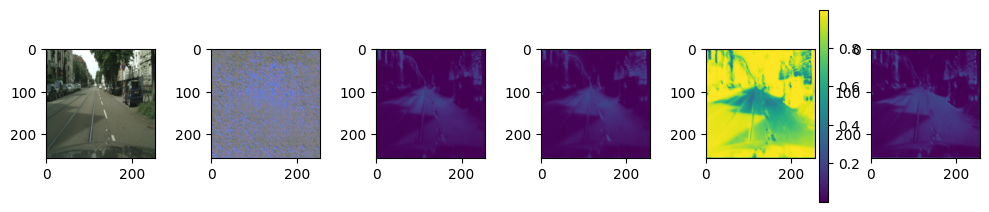

In [4]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)
    y= rec_model(x,seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



vmin = seg_probs[0].min().item()
vmax = seg_probs[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(seg_probs[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()
print(x.mean(),y[-1].mean())

In [5]:
reconstruction_loss_fn  = nn.MSELoss()
entropy_loss_fn = EntropyLoss(weight=0.1)
tv_loss_fn = TotalVariationLoss(weight=5.0) #

In [6]:
# pretrain the rec_model to be good all over the place

epochs =3


for epoch in range(0, epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for data,_ in loop:
        
        rec_model_optimizer.zero_grad()

        full_img = data[-1].to(device)
        b,_,h,w = full_img.shape
        dummy_seg_logits = torch.zeros(b,n_components,h,w,requires_grad=True).to(device)
        dummy_seg_logits[:,0,:,:] = torch.ones_like(dummy_seg_logits[:,0,:,:])
        dummy_seg_probs=  F.softmax(dummy_seg_logits, dim=1)
        reconstructions= rec_model(full_img,dummy_seg_probs)

        recon_loss = 0
        for target_img, pred_img in zip(data, reconstructions):
            target_img = target_img.to(device)
            recon_loss += reconstruction_loss_fn(pred_img, target_img)
            
        recon_loss.backward()
        rec_model_optimizer.step()

        loop.set_postfix(
            recon_loss=recon_loss.item(),
         
        )
    torch.save(rec_model.state_dict(), f'rec_model.pt')
        



Epoch 0/3:  93%|█████████▎| 2316/2500 [04:38<00:22,  8.32it/s, recon_loss=0.0393]


KeyboardInterrupt: 

tensor(-0.3569, device='cuda:0') tensor(-0.3349, device='cuda:0')


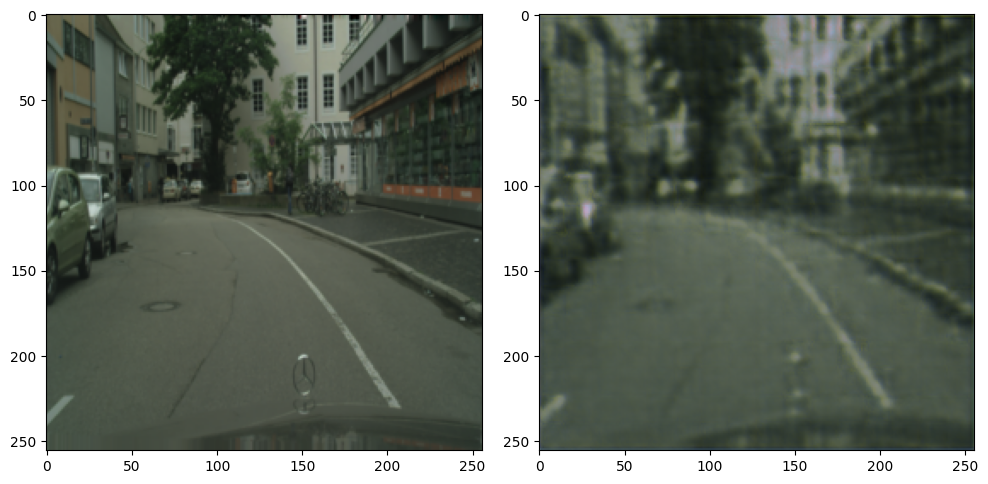

In [8]:
data,_ = next(iter(train_loader)) 
with torch.no_grad():
    full_img = data[-1].to(device)
    b,_,h,w = full_img.shape

    dummy_seg_logits = torch.zeros(b,n_components,h,w,requires_grad=True).to(device)
    dummy_seg_logits[:,0,:,:] = torch.ones_like(dummy_seg_logits[:,0,:,:])    
    dummy_seg_probs = torch.softmax(dummy_seg_logits,dim=1)
    y= rec_model(full_img,dummy_seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2,figsize=(10,5))


show  = 1
scaled_x = scale_for_display(data[-show])
sclaed_y = scale_for_display(y[-show])

ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())


vmin = seg_probs[0].min().item()
vmax = seg_probs[0].max().item()

plt.tight_layout()
print(x.mean(),y[-1].mean())

In [ ]:
epochs =10


for epoch in range(0, epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for data,_ in loop:
        
        seg_model_optimizer.zero_grad()
        rec_model_optimizer.zero_grad()
        full_img = data[-1].to(device)

        seg_logits = seg_model(full_img)
        seg_probs=  F.softmax(seg_logits, dim=1)

        reconstructions= rec_model(full_img,seg_probs)

        recon_loss = 0
        for target_img, pred_img in zip(data, reconstructions):
            target_img = target_img.to(device)
            recon_loss += reconstruction_loss_fn(pred_img, target_img)
            
        # B. Entropy Loss (forces masks to be confident/binary)
        # Passes logits for numerical stability!
        entropy_loss = entropy_loss_fn(seg_logits)
        
        # C. Total Variation Loss (forces masks to be smooth blobs)
        # Passes probabilities!
        tv_loss = tv_loss_fn(seg_probs)

        # 5. Combine and Backpropagate
        loss = recon_loss + entropy_loss + tv_loss

        loss.backward()
        seg_model_optimizer.step()
        rec_model_optimizer.step()

        loop.set_postfix(
            recon_loss=recon_loss.item(),
            entropy_loss=entropy_loss.item(),
            tv_loss=tv_loss.item(),
            loss=loss.item()
        )
    torch.save(seg_model.state_dict(), f'seg_model.pt')
    torch.save(rec_model.state_dict(), f'rec_model.pt')
        



Epoch 0/10:  16%|█▌        | 391/2500 [00:59<05:20,  6.58it/s, entropy_loss=0.00281, loss=0.0663, recon_loss=0.0541, tv_loss=0.00938]

tensor(-0.3467, device='cuda:0') tensor(-0.3412, device='cuda:0')


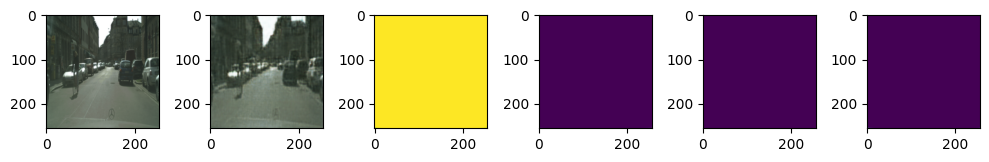

In [ ]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)
    y= rec_model(x,seg_probs)

components = seg_probs.shape[1]

fig,ax = plt.subplots(1,2+components,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())




vmin = seg_probs[0].min().item()
vmax = seg_probs[0].max().item()

for i in range(components):
    im = ax[2 + i].imshow(seg_probs[0, i].cpu().numpy(), vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.5)
plt.tight_layout()
print(x.mean(),y[-1].mean())

0.9996795654296875
0.0001375767751596868
0.00014485818974208087
3.803490108111873e-05


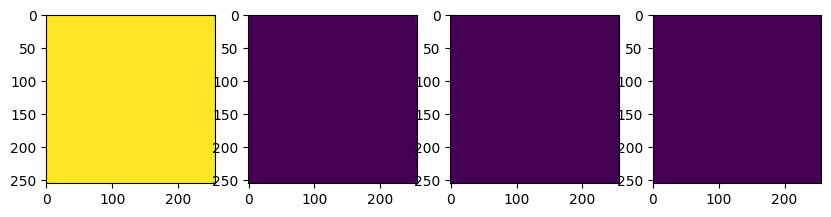

In [ ]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)

fig,ax = plt.subplots(1,components,figsize=(10,10))
for i in range(components):
    # Let matplotlib auto-scale the tiny decimal variations
    im = ax[i].imshow(seg_probs[0, i].cpu().numpy()) 
    print(seg_probs[0, i].cpu().numpy().mean().item())

-0.3457443118095398 -0.34349295496940613 -0.0022513284347951412


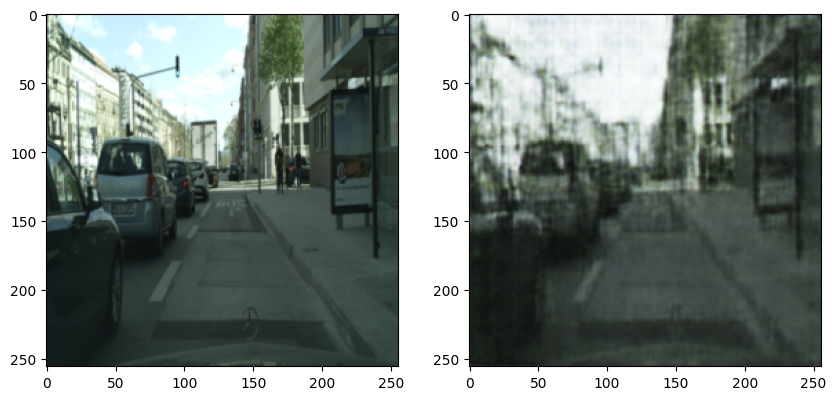

In [ ]:
data,_ = next(iter(train_loader)) 

with torch.no_grad():
    x = data[-1].to(device)
    seg = seg_model(x)
    seg_probs = torch.softmax(seg,dim=1)
    y= rec_model(x,seg_probs)


fig,ax = plt.subplots(1,2,figsize=(10,5))
scaled_x = scale_for_display(x)
sclaed_y = scale_for_display(y[-1])
ax[0].imshow(scaled_x[0].cpu().permute(1,2,0).numpy())
ax[1].imshow(sclaed_y[0].cpu().permute(1,2,0).numpy())



print(x.mean().item(),y[-1].mean().item(),(x-y[-1]).mean().item())